# Información del proyecto

## Propuesta inicial

En un contexto donde plataformas como Spotify o YouTube concentran gran parte del consumo musical, los artistas independientes enfrentan desafíos relacionados con la transparencia en los ingresos, la detección de usos no autorizados de su obra y la optimización de sus estrategias de lanzamiento. Este proyecto propone abordar estas problemáticas mediante el desarrollo de tres módulos principales basados en datos existentes. Los módulos son:

1. Análisis de mercado musical, orientado a identificar patrones de consumo, tendencias por género y oportunidades de monetización para artistas, permitiendo generar recomendaciones estratégicas basadas en datos (por ejemplo, mercados potenciales o características musicales asociadas al éxito).

2. Detección de fraude en streams, mediante técnicas de análisis de comportamiento y modelos de detección de anomalías, con el fin de identificar reproducciones artificiales o manipuladas que afectan la distribución justa de royalties.

3. Predecir qué canción será el próximo éxito de verano

    * Paso 1 (El Problema): Predecir la popularidad (de 0 a 100) de una canción o clasificar a qué género musical exacto pertenece basándose únicamente en sus características acústicas.
    * Paso 2 (Obtención): Usar la API de Spotify. Es facilísimo extraer más de 60.000 canciones. La API te devuelve variables fascinantes: danceability (bailabilidad), energy, acousticness, instrumentalness, liveness, valence (positividad), tempo, duración, explícito (variable categórica), etc. Si las cruzas con otra API (como Genius para contar palabras en la letra), pasas de las 20 variables sobradamente.
    * Paso 3 (Almacenamiento): Guardar todo en una base de datos relacional (como PostgreSQL o MySQL). Puedes crear tablas separadas para "Artistas", "Álbumes" y "Tracks" y hacer consultas JOIN para unirlo todo en Python.
    * Paso 7 (La App Web): Una web en Streamlit donde el jurado pueda introducir el enlace de una canción de Spotify (o subir un archivo de audio si te animas a procesarlo) y la app les diga con un gráfico de barras qué nivel de éxito tendría y qué emociones transmite el modelo.
    Opción 2: El Asistente Estratégico para Streamers de Twitch

## Objetivos del proyecto



* Desarrollar un sistema de análisis de datos que permita comprender el comportamiento del mercado musical digital.

* Implementar modelos de machine learning para predecir el rendimiento de canciones y recomendar estrategias de monetización.

* Diseñar un sistema de detección de anomalías aplicado a datos de streaming para identificar posibles fraudes.

* Construir un prototipo de reconocimiento de audio para la identificación de contenido protegido por derechos de autor.

* Integrar estos componentes en una arquitectura escalable que pueda evolucionar hacia una plataforma real.

## Hipótesis de trabajo



* Es posible predecir el éxito relativo de una canción a partir de variables como sus características de audio, contexto de lanzamiento y métricas de engagement.

* Los patrones de fraude en streaming pueden ser identificados mediante comportamientos anómalos en los datos de escucha, sin necesidad de información sensible como direcciones IP.

* Las técnicas de procesamiento de audio permiten detectar coincidencias entre contenidos musicales con un alto grado de precisión, incluso en entornos ruidosos o transformados.

* El uso combinado de análisis de datos e inteligencia artificial puede ayudar a los artistas independientes a optimizar sus ingresos y tomar decisiones estratégicas más informadas.

# Data encontrada:


* RECOMENDACIONES DE APIS:

**Last.fm:** Úsalo para el **Módulo 1** (tendencias actuales y top tracks) y para obtener datos de comportamiento en tiempo real de usuarios.

**MSD:** Úsalo para el **Módulo 2** si necesitas un volumen de datos histórico muy grande para validar tu modelo de detección de fraude, ya que incluye datos de un millón de canciones y miles de usuarios.

**Módulo 3**

## **Módulo 1. Analisis del mercado musical apra el artista:**

Se usan los datos de Last.fm API ya que  se basan en consumo real de usuarios.

### Imports

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

### API Request 

In [22]:
ret = requests.get(f"https://ws.audioscrobbler.com/2.0/?method=chart.gettoptracks&api_key=63e059c3c912a3f642daf2372484d183&format=json")
ret.json()

{'tracks': {'track': [{'name': 'Stateside + Zara Larsson',
    'duration': '176',
    'playcount': '14285063',
    'listeners': '991175',
    'mbid': 'ffbf7862-2476-4164-ac32-f5904ccefe0f',
    'url': 'https://www.last.fm/music/PinkPantheress/_/Stateside+%252B+Zara+Larsson',
    'streamable': {'#text': '0', 'fulltrack': '0'},
    'artist': {'name': 'PinkPantheress',
     'mbid': '7441014f-f8f5-494f-81db-ff166fbc078d',
     'url': 'https://www.last.fm/music/PinkPantheress'},
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'}]},
   {'name': 'Am

In [23]:
for track in ret.json()["tracks"]["track"]:
  print(track["name"], ". Duracion:", track["duration"],"minutos")

Stateside + Zara Larsson . Duracion: 176 minutos
American Girls . Duracion: 213 minutos
Babydoll . Duracion: 97 minutos
Fame Is a Gun . Duracion: 183 minutos
Dracula . Duracion: 205 minutos
Taste Back . Duracion: 221 minutos
Manchild . Duracion: 213 minutos
Midnight Sun . Duracion: 189 minutos
Ready, Steady, Go! . Duracion: 160 minutos
DtMF . Duracion: 237 minutos
End of Beginning . Duracion: 159 minutos
Aperture . Duracion: 311 minutos
Good Luck, Babe! . Duracion: 218 minutos
The Less I Know the Better . Duracion: 234 minutos
Coming Up Roses . Duracion: 248 minutos
POP . Duracion: 216 minutos
So Easy (To Fall In Love) . Duracion: 170 minutos
Creep . Duracion: 235 minutos
WHERE IS MY HUSBAND! . Duracion: 196 minutos
back to friends . Duracion: 199 minutos
Are you listening yet? . Duracion: 192 minutos
505 . Duracion: 305 minutos
The Waiting Game . Duracion: 169 minutos
NUEVAYoL . Duracion: 184 minutos
No One Noticed . Duracion: 236 minutos
All I Did Was Dream Of You (feat. The Marías) 

In [24]:
music = pd.DataFrame(ret.json()["tracks"]["track"])
music.head()

,name,duration,playcount,listeners,mbid,url,streamable,artist,image
0,Stateside + Zara Larsson,176,14285063,991175,ffbf7862-2476-4164-ac32-f5904ccefe0f,https://www.last.fm/music/PinkPantheress/_/Sta...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'PinkPantheress', 'mbid': '7441014f-f...",[{'#text': 'https://lastfm.freetls.fastly.net/...
1,American Girls,213,2003593,372747,2c85fe70-3c0e-4b43-8d97-f5b5c4757f3a,https://www.last.fm/music/Harry+Styles/_/Ameri...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35...",[{'#text': 'https://lastfm.freetls.fastly.net/...
2,Babydoll,97,21731318,1463687,c6fa2cd4-a100-4db8-8206-3cbcdd3aabe0,https://www.last.fm/music/Dominic+Fike/_/Babydoll,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Dominic Fike', 'mbid': 'e337c918-098...",[{'#text': 'https://lastfm.freetls.fastly.net/...
3,Fame Is a Gun,183,18278530,975949,37907edc-06c1-4d08-b2ef-7e5221986f91,https://www.last.fm/music/Addison+Rae/_/Fame+I...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Addison Rae', 'mbid': '610b71d9-fa78...",[{'#text': 'https://lastfm.freetls.fastly.net/...
4,Dracula,205,8988684,930472,5b1c893a-16da-4e3d-b9b7-6cc57afc360c,https://www.last.fm/music/Tame+Impala/_/Dracula,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Tame Impala', 'mbid': '63aa26c3-d59b...",[{'#text': 'https://lastfm.freetls.fastly.net/...


In [25]:
# Cleaning the data frame:
music.drop(['mbid', 'image', 'url'],axis=1)

,name,duration,playcount,listeners,streamable,artist
0,Stateside + Zara Larsson,176,14285063,991175,"{'#text': '0', 'fulltrack': '0'}","{'name': 'PinkPantheress', 'mbid': '7441014f-f..."
1,American Girls,213,2003593,372747,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35..."
2,Babydoll,97,21731318,1463687,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Dominic Fike', 'mbid': 'e337c918-098..."
3,Fame Is a Gun,183,18278530,975949,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Addison Rae', 'mbid': '610b71d9-fa78..."
4,Dracula,205,8988684,930472,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Tame Impala', 'mbid': '63aa26c3-d59b..."
5,Taste Back,221,1685661,296294,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35..."
6,Manchild,213,22802932,1189985,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Sabrina Carpenter', 'mbid': '1882fe9..."
7,Midnight Sun,189,10464176,643706,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Zara Larsson', 'mbid': '134e6410-695..."
8,"Ready, Steady, Go!",160,1660079,303183,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Harry Styles', 'mbid': '7eb1ce54-a35..."
9,DtMF,237,15458411,1232617,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Bad Bunny', 'mbid': '89aa5ecb-59ad-4..."


### Filtrando ds:
* Nombre y duracion de las canciones
* Comparación de la canción por titulo (happy or sad)
* Duración promedio de los top30 tracks

#### Nombre y duración de las canciones

In [26]:
for track in ret.json()["tracks"]["track"]:
  print(track["name"], ". Duracion:", track["duration"],"minutos")

Stateside + Zara Larsson . Duracion: 176 minutos
American Girls . Duracion: 213 minutos
Babydoll . Duracion: 97 minutos
Fame Is a Gun . Duracion: 183 minutos
Dracula . Duracion: 205 minutos
Taste Back . Duracion: 221 minutos
Manchild . Duracion: 213 minutos
Midnight Sun . Duracion: 189 minutos
Ready, Steady, Go! . Duracion: 160 minutos
DtMF . Duracion: 237 minutos
End of Beginning . Duracion: 159 minutos
Aperture . Duracion: 311 minutos
Good Luck, Babe! . Duracion: 218 minutos
The Less I Know the Better . Duracion: 234 minutos
Coming Up Roses . Duracion: 248 minutos
POP . Duracion: 216 minutos
So Easy (To Fall In Love) . Duracion: 170 minutos
Creep . Duracion: 235 minutos
WHERE IS MY HUSBAND! . Duracion: 196 minutos
back to friends . Duracion: 199 minutos
Are you listening yet? . Duracion: 192 minutos
505 . Duracion: 305 minutos
The Waiting Game . Duracion: 169 minutos
NUEVAYoL . Duracion: 184 minutos
No One Noticed . Duracion: 236 minutos
All I Did Was Dream Of You (feat. The Marías) 

#### Comparación de grupos (canciones 'happy'-'sad'):

In [27]:
df_happy = music[music['name'].str.contains('happy',case=False,na=False)]
df_happy.count()

name          0
duration      0
playcount     0
listeners     0
mbid          0
url           0
streamable    0
artist        0
image         0
dtype: int64

In [28]:
df_sad = music[music['name'].str.contains('sad', case=False, na=False)]
df_sad.count()

name          0
duration      0
playcount     0
listeners     0
mbid          0
url           0
streamable    0
artist        0
image         0
dtype: int64

#### Duración promedio de top30 tracks:

In [29]:
df_top30_duration = music.sort_values(by='playcount', ascending=False) # .head(30)
df_top30_duration.iloc[:30]
df_top30_duration.head()


,name,duration,playcount,listeners,mbid,url,streamable,artist,image
18,WHERE IS MY HUSBAND!,196,9559190,901032,127fd962-d85c-4f64-84e1-220f3dae762c,https://www.last.fm/music/RAYE/_/WHERE+IS+MY+H...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'RAYE', 'mbid': '8be564c3-dfba-440b-a...",[{'#text': 'https://lastfm.freetls.fastly.net/...
4,Dracula,205,8988684,930472,5b1c893a-16da-4e3d-b9b7-6cc57afc360c,https://www.last.fm/music/Tame+Impala/_/Dracula,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Tame Impala', 'mbid': '63aa26c3-d59b...",[{'#text': 'https://lastfm.freetls.fastly.net/...
29,Man I Need,184,8483616,804725,3161a467-1441-4ef8-8ca0-424db271cd79,https://www.last.fm/music/Olivia+Dean/_/Man+I+...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Olivia Dean', 'mbid': '15e0d608-0869...",[{'#text': 'https://lastfm.freetls.fastly.net/...
16,So Easy (To Fall In Love),170,7563569,808332,NaN,https://www.last.fm/music/Olivia+Dean/_/So+Eas...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'Olivia Dean', 'mbid': '15e0d608-0869...",[{'#text': 'https://lastfm.freetls.fastly.net/...
46,I Thought I Saw Your Face Today,185,7288059,868222,06332d33-891e-32ac-98c4-f564e7babffd,https://www.last.fm/music/She+&+Him/_/I+Though...,"{'#text': '0', 'fulltrack': '0'}","{'name': 'She & Him', 'mbid': 'fb821608-35fd-4...",[{'#text': 'https://lastfm.freetls.fastly.net/...


In [30]:
df_top30_duration.loc[:, 'duration'] = pd.to_numeric(df_top30_duration['duration'], errors='coerce')
mean = df_top30_duration['duration'].mean()
mean

TypeError: Invalid value '[196 205 184 170 185 235   0 218 305 180 175 222 213 240 311 234 203 337
 236 159 236 289 403 237 226 199 213  97 209 213 224 183 221 160 237 216
 248 204 160 192 176 229 169 194 201 253 368 184 189   0]' for dtype 'str'

### Procedencia de los artisitas top10: 
* Oyentes de artists top10

In [ ]:
# Info api request:
ret_artist = requests.get(f"https://ws.audioscrobbler.com/2.0/?method=geo.gettopartists&country=spain&api_key=63e059c3c912a3f642daf2372484d183&format=json")
ret_artist.json()

{'topartists': {'artist': [{'name': 'Bad Bunny',
    'listeners': '13312',
    'mbid': '89aa5ecb-59ad-46f5-b3eb-2d424e941f19',
    'url': 'https://www.last.fm/music/Bad+Bunny',
    'streamable': '0',
    'image': [{'#text': 'https://lastfm.freetls.fastly.net/i/u/34s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'small'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/64s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'medium'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/174s/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'large'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'extralarge'},
     {'#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/2a96cbd8b46e442fc41c2b86b821562f.png',
      'size': 'mega'}],
    '@attr': {'rank': '1'}},
   {'name': 'ROSALÍA',
    'listeners': '8847',
    'mbid': '25f3abd9-63b5-471a-bd25-feb9672dfa11',
    'url': 'https://www.last.fm/music/ROSA

In [ ]:
artists_country = pd.DataFrame(ret_artist.json()["topartists"]["artist"])
artists_country.head()

,name,listeners,mbid,url,streamable,image,@attr
0,Bad Bunny,13312,89aa5ecb-59ad-46f5-b3eb-2d424e941f19,https://www.last.fm/music/Bad+Bunny,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '1'}
1,ROSALÍA,8847,25f3abd9-63b5-471a-bd25-feb9672dfa11,https://www.last.fm/music/ROSAL%C3%8DA,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '2'}
2,Bad Gyal,8632,9cb2e99f-d0ba-4aa5-a371-0006b0d34090,https://www.last.fm/music/Bad+Gyal,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '3'}
3,Taylor Swift,8578,20244d07-534f-4eff-b4d4-930878889970,https://www.last.fm/music/Taylor+Swift,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '4'}
4,Charli xcx,8114,260b6184-8828-48eb-945c-bc4cb6fc34ca,https://www.last.fm/music/Charli+xcx,0,[{'#text': 'https://lastfm.freetls.fastly.net/...,{'rank': '5'}


#### Oyentes de los artistas top 10:

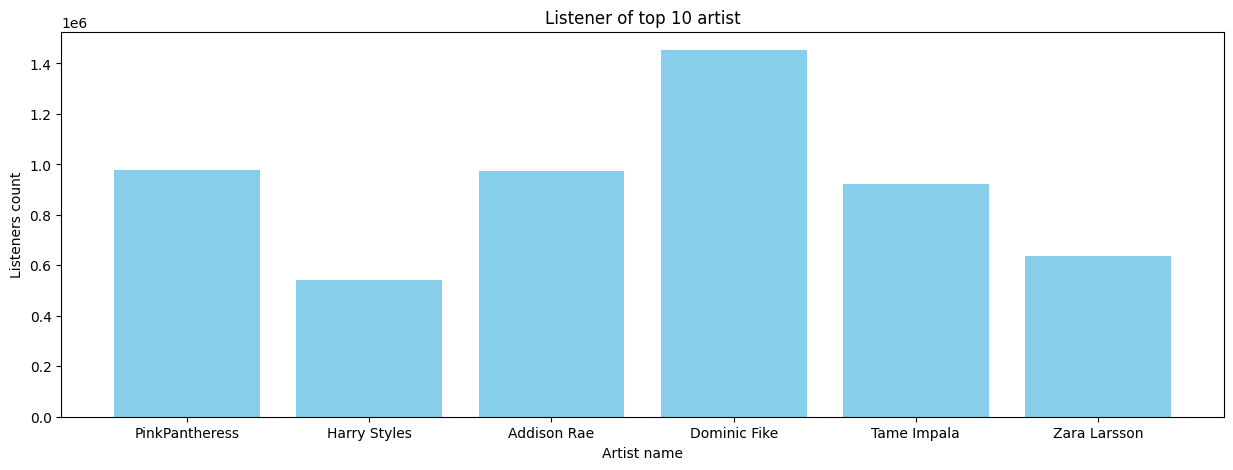

In [ ]:
df_top10 = music.head(10)
df_top10['duration'] = pd.to_numeric(df_top10['duration'], errors='coerce')
df_top10['listeners'] = pd.to_numeric(df_top10['listeners'], errors='coerce')

df_top10['artist_name'] = df_top10['artist'].apply(lambda x: x['name'])

plt.figure(figsize = (15, 5))

plt.bar(df_top10['artist_name'], df_top10['listeners'], color = ['skyblue'])
plt.xlabel('Artist name')
plt.ylabel('Listeners count')
plt.title("Listener of top 10 artist")
plt.show()

### Géneros musicales en tendencia global

In [ ]:

def get_trending_tags(api_key):
    url = f"https://ws.audioscrobbler.com/2.0/?method=tag.getTopTags&api_key={api_key}&format=json"
    response = requests.get(url)
    return response.json()['toptags']['tag']

api_key = '63e059c3c912a3f642daf2372484d183'
get_trending_tags(api_key)

[{'name': 'rock', 'count': 4069237, 'reach': 402894},
 {'name': 'electronic', 'count': 2498601, 'reach': 262196},
 {'name': 'seen live', 'count': 2194460, 'reach': 82557},
 {'name': 'alternative', 'count': 2130888, 'reach': 267196},
 {'name': 'pop', 'count': 2082394, 'reach': 233753},
 {'name': 'indie', 'count': 2065324, 'reach': 260434},
 {'name': 'female vocalists', 'count': 1634464, 'reach': 169157},
 {'name': 'metal', 'count': 1305623, 'reach': 159014},
 {'name': 'alternative rock', 'count': 1230081, 'reach': 170245},
 {'name': 'jazz', 'count': 1196406, 'reach': 149971},
 {'name': 'classic rock', 'count': 1149319, 'reach': 137113},
 {'name': 'ambient', 'count': 1125337, 'reach': 150169},
 {'name': 'experimental', 'count': 1111936, 'reach': 145396},
 {'name': 'folk', 'count': 958605, 'reach': 151353},
 {'name': 'indie rock', 'count': 928875, 'reach': 137424},
 {'name': 'punk', 'count': 919672, 'reach': 145492},
 {'name': 'Hip-Hop', 'count': 919197, 'reach': 131432},
 {'name': 'hard 

In [ ]:
ret_generes = get_trending_tags(api_key)
top_generes = pd.DataFrame(ret_generes)[['name', 'count', 'reach']]
top_generes.head()

,name,count,reach
0,rock,4069237,402894
1,electronic,2498601,262196
2,seen live,2194460,82557
3,alternative,2130888,267196
4,pop,2082394,233753


## **Módulo 2. Fraude en streams:**

* Se usan los datos de Last.fm API también. --> Completar al decidir

* Objetivo: Analizar el comportamiento de los usuarios para detectar anomalias. A través de la informaticón de timestamps y time_between_streams de podría averiguar si esa cuenta ussuario es un humano o un bot.

* EDA: analisis outliers- usarios vs diferencia de tiempo

* ML: clusterung

#### Obtener el historial de un usuario para revisar anomalías

In [ ]:
# api_key = '63e059c3c912a3f642daf2372484d183'
# username = ['listeners'] # duda como sacarlo¿?
# def check_user_activity(api_key, username):
#     url = f"https://ws.audioscrobbler.com/2.0/?method=user.getRecentTracks&user={username}&api_key={api_key}&format=json"
#     data = requests.get(url).json()
#     # Aquí podrías calcular la diferencia de tiempo entre tracks (feature engineering) [5]
#     return data['recenttracks']['track']

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, **kwargs)
        ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/iostream.py", line 105, in _handle_subscription
    event_type = frame[0]
                 ~~~~~^^^
IndexError: index out of range
ERROR:tornado.general:Uncaught exception in zmqstream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 600, in _handle_events
    self._handle_recv()
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 550, in _run_callback
    f = callback(*args, 

#### Obtener lista de usuarios a través de amigos del usuario 'rj'

* Con api Freesound:

In [31]:
import requests
import pandas as pd

API_KEY = "63e059c3c912a3f642daf2372484d183"

def get_user_friends(username):
    """Obtiene la lista de amigos de un usuario para expandir la base de datos."""
    url = f"https://ws.audioscrobbler.com/2.0/?method=user.getfriends&user={username}&api_key={API_KEY}&format=json"
    response = requests.get(url).json()
    # Extraemos solo los nombres de usuario de la lista de amigos
    if 'friends' in response:
        return [friend['name'] for friend in response['friends']['user']]
    return []

def get_recent_tracks(username):
    """Obtiene el historial reciente para detectar patrones de fraude."""
    url = f"https://ws.audioscrobbler.com/2.0/?method=user.getrecenttracks&user={username}&api_key={API_KEY}&format=json"
    data = requests.get(url).json()
    if 'recenttracks' in data:
        return data['recenttracks']['track']
    return []


In [32]:
# Empezamos con 'rj' y buscamos a sus amigos
lista_usuarios = get_user_friends("rj")
lista_usuarios[:5]

['Babs_05', 'franhale', 'eartle', 'massdosage', 'Knapster01']

#### Recolectamos en un al ista los datos de escucha de esos nuevos usuarios

In [ ]:
lista_total_escuchas = []
for user in lista_usuarios[:5]:  # Limitamos a 5 para el ejemplo
    tracks = get_recent_tracks(user)
    for t in tracks:
        t['user_id'] = user  # Añadimos el ID de usuario para el análisis [3]
        lista_total_escuchas.append(t)


In [ ]:
# Creamos el DataFrame para EDA 
df_escuchas = pd.DataFrame(lista_total_escuchas)


,artist,streamable,image,mbid,album,name,@attr,url,user_id,date
0,{'mbid': '6bd920ac-3b7c-47e0-8f0f-c390f63f5112...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",188364cf-7e65-4137-843d-3cf19a086b34,{'mbid': '1bdd52a8-2794-4aa8-89a2-591775104276...,Stranger,{'nowplaying': 'true'},https://www.last.fm/music/Anna+von+Hausswolff/...,Babs_05,NaN
1,{'mbid': '8b16f1e6-d960-432b-92d1-70fc3e61176d...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",7908a3a7-66f7-4160-b1d1-bff397d8b3f7,{'mbid': 'a50a1d1e-543b-4aed-910f-06ec9809060c...,Peace Song,NaN,https://www.last.fm/music/Fat+Dog/_/Peace+Song,Babs_05,"{'uts': '1773853109', '#text': '18 Mar 2026, 1..."
2,"{'mbid': '', '#text': 'James Blake'}",0,"[{'size': 'small', '#text': 'https://lastfm.fr...",,"{'mbid': '', '#text': 'BAD CAMEO'}",In Grey,NaN,https://www.last.fm/music/James+Blake/_/In+Grey,Babs_05,"{'uts': '1773852738', '#text': '18 Mar 2026, 1..."
3,{'mbid': '52074ba6-e495-4ef3-9bb4-0703888a9f68...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",,{'mbid': 'c5a6a982-b630-441c-a4df-1b821b89e112...,End of The Empire I-III,NaN,https://www.last.fm/music/Arcade+Fire/_/End+of...,Babs_05,"{'uts': '1773852415', '#text': '18 Mar 2026, 1..."
4,{'mbid': '4dbf34ad-4156-4587-8532-4219cb4fa373...,0,"[{'size': 'small', '#text': 'https://lastfm.fr...",a005f6b8-f326-469d-b17e-a92ad14001b3,{'mbid': '82a7521e-d611-46ba-b623-58ad9bda28e6...,Count Your Blessings,NaN,https://www.last.fm/music/Mattiel/_/Count+Your...,Babs_05,"{'uts': '1773852215', '#text': '18 Mar 2026, 1..."


In [ ]:
df_escuchas['artist'][0] # muestra de datos guardados en el diccionario de la columna artist

{'mbid': '6bd920ac-3b7c-47e0-8f0f-c390f63f5112',
 '#text': 'Anna von Hausswolff'}

In [ ]:
# Limpieza:

## En algunas filas se encuentra información guardada en diccionarios y solo queremos visualizar un dato.
df_escuchas['artist'] = df_escuchas['artist'].apply(lambda x: x['#text'] if isinstance(x, dict) else x)
df_escuchas['date'] = df_escuchas['date'].apply(lambda x: x['#text'] if isinstance(x, dict) else x) # --> limpiar mejor la fecha, hacer oclumna separada para la hora de la escucha

## Elimino las columnas que no interesan para este análissi de escuchas.
df_escuchas.drop(['mbid','album','url','image','@attr'],axis=1)


,artist,streamable,name,user_id,date
0,Anna von Hausswolff,0,Stranger,Babs_05,NaN
1,Fat Dog,0,Peace Song,Babs_05,"18 Mar 2026, 16:58"
2,James Blake,0,In Grey,Babs_05,"18 Mar 2026, 16:52"
3,Arcade Fire,0,End of The Empire I-III,Babs_05,"18 Mar 2026, 16:46"
4,Mattiel,0,Count Your Blessings,Babs_05,"18 Mar 2026, 16:43"
...,...,...,...,...,...
247,The Funkyverse,0,And Eternity,Knapster01,"14 Mar 2026, 23:57"
248,The Funkyverse,0,And Eternity,Knapster01,"14 Mar 2026, 16:24"
249,Thing,0,Lost In The Haze,Knapster01,"14 Mar 2026, 15:59"
250,setting,0,Gum Bump,Knapster01,"14 Mar 2026, 15:52"


#### Detección de Anomalías (Análisis de Timestamps)

* Para identificar reproducciones artificiales, el método clave en Last.fm es user.getRecentTracks. Este recurso devuelve una lista de canciones escuchadas recientemente con timestamps exactos, lo que permite calcular el intervalo de tiempo entre cada reproducción.
* DATA: 
· En tiempo real desde Freesound: Usando el método user.getRecentTracks para cualquier usuario activo en la plataforma.
· Histórico masivo: En el Taste Profile subset del Million Song Dataset (MSD), que contiene datos de escucha de usuarios recopilados específicamente para investigación comercial. -> DUDA 

* Código para Detección de Anomalías (Análisis de Timestamps). Este código calcula el time_between_streams y el repeat_count, que son las variables que propusiste para detectar patrones de bots.


In [ ]:
# API Request
ret = requests.get(f"https://ws.audioscrobbler.com/2.0/?method=user.getRecentTracks&user='rj'&api_key=63e059c3c912a3f642daf2372484d183&format=json")
ret.json()

{'message': 'User not found', 'error': 6}

In [44]:
def time_between_streams(API_KEY, username):
    # Petición clave para ver el historial con timestamps [4]
    url = f"https://ws.audioscrobbler.com/2.0/?method=user.getRecentTracks&user={username}&api_key={API_KEY}&format=json"
    response = requests.get(url).json()
    tracks = response['recenttracks']['track']
    
    # Creamos un DataFrame para procesar los patrones temporales [7]
    data = []
    for t in tracks:
        if 'date' in t: # Solo tracks que ya terminaron de sonar
            data.append({
                'track': t['name'],
                'timestamp': int(t['date']['uts']) # Unix timestamp
            })
    
    df = pd.DataFrame(data)
    
    # Feature Engineering para anomalías [7]:
    # 1. Calcular tiempo entre canciones (en segundos)
    df['time_between_streams'] = df['timestamp'].diff().abs()
    
    # 2. Detectar reproducciones consecutivas de la misma canción (repeat_count)
    df['is_repeat'] = df['track'] == df['track'].shift()
    
    return df

In [ ]:
# Reutilizo la lista de usuarios iniciales de Last.fm API
API_KEY = "63e059c3c912a3f642daf2372484d183"
time_between_streams(API_KEY, 'rj')


{'recenttracks': {'track': [{'artist': {'mbid': '084308bd-1654-436f-ba03-df6697104e19', '#text': 'Green Day'}, 'streamable': '0', 'image': [{'size': 'small', '#text': 'https://lastfm.freetls.fastly.net/i/u/34s/24aea77a395f08bed4495b82ba25bbd1.jpg'}, {'size': 'medium', '#text': 'https://lastfm.freetls.fastly.net/i/u/64s/24aea77a395f08bed4495b82ba25bbd1.jpg'}, {'size': 'large', '#text': 'https://lastfm.freetls.fastly.net/i/u/174s/24aea77a395f08bed4495b82ba25bbd1.jpg'}, {'size': 'extralarge', '#text': 'https://lastfm.freetls.fastly.net/i/u/300x300/24aea77a395f08bed4495b82ba25bbd1.jpg'}], 'mbid': '', 'album': {'mbid': '', '#text': 'Nimrod (25th Anniversary Edition)'}, 'name': 'Jaded - Live at the Electric Factory, Philadelphia 11/14/97', 'url': 'https://www.last.fm/music/Green+Day/_/Jaded+-+Live+at+the+Electric+Factory,+Philadelphia+11%2F14%2F97', 'date': {'uts': '1773870674', '#text': '18 Mar 2026, 21:51'}}, {'artist': {'mbid': '084308bd-1654-436f-ba03-df6697104e19', '#text': 'Green Day'}

,track,timestamp,time_between_streams,is_repeat
39,Nice Guys Finish Last,1773864068,211.0,True


In [ ]:
lista_usuarios

['Babs_05',
 'franhale',
 'eartle',
 'massdosage',
 'Knapster01',
 'jonocole',
 'isaac',
 'lobsterclaw',
 'jajo',
 'mremond',
 'Orlenay',
 'schlagschnitzel',
 'Edouard',
 'naniel',
 'dunk',
 'RUPERT',
 'mxcl',
 'jwheare',
 'nancyvw',
 'underpangs',
 'p_wheel',
 'spietsch',
 'musicmobs',
 'Schrollum',
 'luke_10',
 'tgwizard',
 'pkeanecbs',
 'Roelven',
 'BecFrost',
 'gracehn001',
 'saulklein',
 'arrdis',
 'jarvis',
 'fascinated',
 'noirsette',
 'marquezmj',
 'julians',
 'david',
 'pellitero',
 'claoi',
 'grazziee',
 'clairewkyb',
 'lumberjack',
 'foreverautumn',
 'Yllona',
 'cakemix',
 'Jonty',
 'nova77LF',
 'muz',
 'mischa']

In [48]:
import pandas as pd

lista_usuarios = get_user_friends("rj")

lista_tbs = []

for user in lista_usuarios:
    print(user)
    try:
        df_tbs = time_between_streams(API_KEY, user)
        
        # opcional: añadir columna con el usuario
        df_tbs["user"] = user
        
        lista_tbs.append(df_tbs)
        
    except Exception as e:
        print(f"Error con {user}: {e}")

# Unir todos los dataframes
df_final = pd.concat(lista_tbs, ignore_index=True)

df_final


Babs_05
franhale
eartle
massdosage
Knapster01
jonocole
isaac
lobsterclaw
jajo
mremond
Orlenay
schlagschnitzel
Error con schlagschnitzel: 'recenttracks'
Edouard
naniel
dunk
RUPERT
mxcl
jwheare
nancyvw
underpangs
p_wheel
spietsch
musicmobs
Schrollum
Error con Schrollum: 'recenttracks'
luke_10
tgwizard
pkeanecbs
Roelven
BecFrost
gracehn001
saulklein
arrdis
jarvis
fascinated
noirsette
marquezmj
julians
david
Error con david: 'recenttracks'
pellitero
claoi
grazziee
clairewkyb
lumberjack
foreverautumn
Yllona
cakemix
Jonty
nova77LF
muz
mischa


,track,timestamp,time_between_streams,is_repeat,user
0,Evergreen,1773991623,NaN,False,Babs_05
1,Caught in the Blink of an Eye,1773991399,224.0,False,Babs_05
2,Metaphysica,1773991100,299.0,False,Babs_05
3,"Free, Free",1773990739,361.0,False,Babs_05
4,Sing,1773990508,231.0,False,Babs_05
...,...,...,...,...,...
2345,"Sonate da camera a tre, Op. 2 No. 1 in D Major...",1772485076,81.0,False,mischa
2346,"Scottish Fantasy, Op. 46 - Allegro",1772483082,1994.0,False,mischa
2347,"Sonate da Chiesa a tre, Op. 3 No. 12 in A Majo...",1772482990,92.0,False,mischa
2348,"Author Of Light - First Booke Of Ayres, Arrang...",1772482924,66.0,False,mischa


In [49]:
df_final['user'].nunique()

47

In [ ]:
# DUDA: CONTINUA
#  siguiente paso: hacer graficos de tbs comparar con actividad user (canciones: track, is_repeat)
# cambiar timestamp a formato fecha

#### Con API MSD

In [ ]:
# Con API MSD
data_users_msd = 'http://millionsongdataset.com/sites/default/files/tasteprofile/taste_profile_usercat_120k.txt'
df_users_msd = pd.read_csv(data_users_msd,sep='\t',header=None,names=['user_id', 'song_id', 'play_count'])

In [ ]:
import pandas as pd

# Conceptualmente, así cargarías el subconjunto de datos de usuarios (Taste Profile)
# Este dataset suele venir en formato triplet (user_id, song_id, play_count)
def load_msd_user_data(file_path):
    # Cargamos el archivo (ejemplo con un archivo de texto tabulado)
    df_msd = pd.read_csv(file_path, sep='\t', names=['user_id', 'song_id', 'play_count'])
    
    # Feature Engineering para Detección de Fraude [3]:
    # Calculamos el 'repeat_ratio' que propusiste en tu documentación
    user_stats = df_msd.groupby('user_id')['play_count'].agg(['sum', 'max']).reset_index()
    user_stats['repeat_ratio'] = user_stats['max'] / user_stats['sum']
    
    # Identificamos posibles anomalías (por ejemplo, alguien que escucha una sola canción el 90% del tiempo)
    posibles_bots = user_stats[user_stats['repeat_ratio'] > 0.9]
    return posibles_bots

In [ ]:
data_users_msd = 'http://millionsongdataset.com/sites/default/files/tasteprofile/taste_profile_usercat_120k.txt'
load_msd_user_data(data_users_msd)

,user_id,sum,max,repeat_ratio



**NOTAS**

* Pipeline:

stream logs
↓
feature engineering
↓
EDA
↓
anomaly detection
↓
fraud score

* Modelo  ML debe buscar patrones como: 1000 streams, desde 1 usuario, en 1 hora, duración promedio 5 segundos

## **Módulo 3**